# Phase 3 — Lambda Sensitivity Sweep

**First Phase 3 ablation.** Maps the retrieval landscape over loss-term weights $(\lambda_{VC}, \lambda_{TC})$, treating $\lambda_{VT} = 1$ as the fixed base of the contrastive objective. This characterizes how the third modality's contribution to retrieval changes as its two loss-component weights vary.

**Run matrix:** $\lambda_{VC} \in \{0, 0.25, 0.5, 1, 2, 4\}$ $\times$ $\lambda_{TC} \in \{0, 0.25, 0.5, 1, 2, 4\}$ $\times$ 2 captions $\times$ 3 seeds = **216 runs**.

**Phase 2 anchors recovered by the grid:**
- $(\lambda_{VC}, \lambda_{TC}) = (0, 0)$ → B1 (bi-modal baseline)
- $(\lambda_{VC}, \lambda_{TC}) = (1, 0)$ → M-no-TC
- $(\lambda_{VC}, \lambda_{TC}) = (0, 1)$ → M-no-VC
- $(\lambda_{VC}, \lambda_{TC}) = (1, 1)$ → M-full

These 4 cells were already established in Phase 2; this notebook re-runs them under identical conditions and adds 32 new cells × 2 captions × 3 seeds = 192 fresh runs.

## 0. Setup

In [1]:
!pip install open_clip_torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires num

In [2]:
import json
import math
import random
import time
from copy import deepcopy
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import open_clip
from huggingface_hub import hf_hub_download
from sklearn.model_selection import train_test_split

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## 1. Configuration

The sweep grid and the run config dataclass. Hyperparameters held constant across all runs are identical to Phase 2, so any change in test mR is attributable purely to the $(\lambda_{VC}, \lambda_{TC})$ axis.

In [ ]:
# --- Dataset paths ---
DATASET_ROOT = Path('/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset')
CSV_PATH  = DATASET_ROOT / 'captions.csv'
IMG_DIR = DATASET_ROOT / 'images'

# --- Output paths ---
SPLIT_DIR = Path('splits');   SPLIT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('results');  RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR = Path('figures');  FIGURE_DIR.mkdir(exist_ok=True)

SPLIT_CSV = SPLIT_DIR   / 'comprs_split.csv'
RESULTS_JSON = RESULTS_DIR / 'phase3_lambda_sweep.json'

COMP_COLS = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CAPTIONS = ['vision_qwen3-vl-8b', 'hybrid_qwen3-vl-8b']
SEEDS = [42, 123, 7]
LAMBDA_GRID = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0] # values for both lambda_VC and lambda_TC
LAMBDA_VT_FIXED = 1.0 # always-on base contrastive loss, not a controlled variable of my research question

# --- Recall cut-offs ---
K_VALUES = [1, 5, 10]

# --- Same split sizes from phase 2 ---
N_TRAIN, N_VAL, N_TEST = 7000, 1000, 2000
SPLIT_SEED = 42

assert CSV_PATH.exists(), f'captions.csv not found at {CSV_PATH}'
assert IMG_DIR.exists(),  f'images/ folder not found at {IMG_DIR}'

# Sanity check: enumerate the sweep
total_cells = len(LAMBDA_GRID) ** 2
total_runs  = total_cells * len(CAPTIONS) * len(SEEDS)
print(f'Grid: {len(LAMBDA_GRID)} x {len(LAMBDA_GRID)} = {total_cells} cells per caption')
print(f'Total runs: {total_cells} x {len(CAPTIONS)} captions x {len(SEEDS)} seeds = {total_runs}')

Grid: 6 x 6 = 36 cells per caption
Total runs: 36 x 2 captions x 3 seeds = 216


In [ ]:
@dataclass
class RunConfig:
    # Run-matrix axes
    caption: str
    lambda_vc: float
    lambda_tc: float
    seed: int

    # Constants across the sweep
    epochs: int = 20
    batch_size: int = 32
    lr: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    lambda_vt: float = LAMBDA_VT_FIXED
    initial_temp: float = 0.07
    mlp_hidden: List[int] = field(default_factory=lambda: [128, 256])
    embed_dim: int = 512

    def run_id(self) -> str:
        return f'vc{self.lambda_vc}_tc{self.lambda_tc}_{self.caption}_s{self.seed}'

    @property
    def is_trimodal(self) -> bool:
        # If both comp losses are zero, this is effectively the B1 bi-modal model
        return self.lambda_vc > 0 or self.lambda_tc > 0

## 2. Canonical Split

Identical to Phase 2: load if present, rebuild deterministically with the same seed if not.

In [6]:
df = pd.read_csv(CSV_PATH)
df['dominant_class'] = df[COMP_COLS].values.argmax(axis=1)
df['dominant_class'] = df['dominant_class'].map(lambda i: COMP_COLS[i])
print(f'Total rows: {len(df)}')

Total rows: 10000


In [7]:
if SPLIT_CSV.exists():
    print(f'Found canonical split at {SPLIT_CSV}; loading.')
    split_df = pd.read_csv(SPLIT_CSV)
else:
    print(f'No canonical split at {SPLIT_CSV}; rebuilding with seed={SPLIT_SEED}.')
    if len(df) > N_TRAIN + N_VAL + N_TEST:
        df_sub, _ = train_test_split(
            df, train_size=N_TRAIN + N_VAL + N_TEST,
            stratify=df['dominant_class'], random_state=SPLIT_SEED,
        )
    else:
        df_sub = df.copy()
    df_trainval, df_test = train_test_split(
        df_sub, test_size=N_TEST,
        stratify=df_sub['dominant_class'], random_state=SPLIT_SEED,
    )
    df_train, df_val = train_test_split(
        df_trainval, test_size=N_VAL,
        stratify=df_trainval['dominant_class'], random_state=SPLIT_SEED,
    )
    split_df = (pd.concat([
        df_train.assign(comprs_split='train'),
        df_val.assign(comprs_split='val'),
        df_test.assign(comprs_split='test'),
    ]).sort_values('filename').reset_index(drop=True)[['filename', 'comprs_split']])
    split_df.to_csv(SPLIT_CSV, index=False)
    print(f'Split saved: {SPLIT_CSV}')

df = df.merge(split_df, on='filename', how='inner')
df_train = df[df['comprs_split'] == 'train'].reset_index(drop=True)
df_val   = df[df['comprs_split'] == 'val'  ].reset_index(drop=True)
df_test  = df[df['comprs_split'] == 'test' ].reset_index(drop=True)
print(f'Train/Val/Test sizes: {len(df_train)} / {len(df_val)} / {len(df_test)}')

No canonical split at splits/comprs_split.csv; rebuilding with seed=42.
Split saved: splits/comprs_split.csv
Train/Val/Test sizes: 7000 / 1000 / 2000


## 3. Load Frozen RemoteCLIP & Build Feature Cache

Same recipe as Phase 2: load the HuggingFace RemoteCLIP-ViT-B/32 checkpoint into an `open_clip` ViT-B/32, freeze it, encode every image and every (image, caption-column) once, cache the resulting features as CPU tensors.

In [8]:
print('Downloading RemoteCLIP-ViT-B-32 weights...')
checkpoint_path = hf_hub_download(
    repo_id='chendelong/RemoteCLIP',
    filename='RemoteCLIP-ViT-B-32.pt',
    cache_dir='checkpoints',
)
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32')
clip_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_model = clip_model.to(DEVICE)
for p in clip_model.parameters():
    p.requires_grad = False
clip_model.eval()
print('RemoteCLIP loaded and frozen.')

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

RemoteCLIP loaded and frozen.


In [9]:
class _SplitImageDataset(Dataset):
    """Dataset used only during precomputation, returns image tensors in row order."""
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = self.img_dir / self.df.iloc[idx]["filename"]
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new("RGB", (224, 224), (0, 0, 0))
        return self.transform(image), idx

@torch.no_grad()
def precompute_image_features(df_split, img_dir, transform, model, device, batch_size=64):
    ds = _SplitImageDataset(df_split, img_dir, transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    chunks = []
    for imgs, _ in dl:
        imgs = imgs.to(device, non_blocking=True)
        feat = F.normalize(model.encode_image(imgs), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

@torch.no_grad()
def precompute_text_features(captions, tokenizer, model, device, batch_size=64):
    chunks = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i + batch_size]
        tokens = tokenizer(batch).to(device)
        feat = F.normalize(model.encode_text(tokens), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

def composition_to_tensor(df_split, comp_cols):
    raw = df_split[comp_cols].values.astype(np.float32) / 100.0
    return torch.from_numpy(raw)

SPLITS = {"train": df_train, "val": df_val, "test": df_test}

print("Precomputing image features per split...")
t0 = time.time()
image_features = {name: precompute_image_features(dfs, IMG_DIR, clip_preprocess, clip_model, DEVICE)
                  for name, dfs in SPLITS.items()}
print(f"  done in {time.time() - t0:.1f}s")

print("Precomputing text features per split per caption column...")
t0 = time.time()
text_features = {name: {} for name in SPLITS}
for caption_col in CAPTIONS:
    for name, dfs in SPLITS.items():
        text_features[name][caption_col] = precompute_text_features(
            dfs[caption_col].astype(str).tolist(), clip_tokenizer, clip_model, DEVICE
        )
print(f"  done in {time.time() - t0:.1f}s")

print("Building composition vector tensors...")
comp_vectors = {name: composition_to_tensor(dfs, COMP_COLS) for name, dfs in SPLITS.items()}
print("Feature cache ready.\n")

Precomputing image features per split...
  done in 57.1s
Precomputing text features per split per caption column...
  done in 43.5s
Building composition vector tensors...
Feature cache ready.



## 4. Model Components

Identical to Phase 2. Two trainable linear projections (identity-init), a composition MLP, a learnable log-tau temperature. The model topology never changes; only the loss weights $(\lambda_{VC}, \lambda_{TC})$ do.

In [ ]:
class CompositionMLP(nn.Module):
    """Maps 7-dim composition vector to the 512-dim shared embedding space."""
    def __init__(self, in_dim=7, hidden=(128, 256), out_dim=512):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def build_run_components(cfg, device):
    vp = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    tp = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    nn.init.eye_(vp.weight)
    nn.init.eye_(tp.weight)

    log_tau = nn.Parameter(
        torch.tensor(math.log(1.0 / cfg.initial_temp), dtype=torch.float32, device=device)
    )

    cm = CompositionMLP(in_dim=7, hidden=cfg.mlp_hidden, out_dim=cfg.embed_dim).to(device) \
         if cfg.is_trimodal else None

    params = list(vp.parameters()) + list(tp.parameters()) + [log_tau]
    if cm is not None:
        params += list(cm.parameters())
    return vp, tp, cm, log_tau, params

## 5. Loss Function, Cached Dataset, and Retrieval Evaluator

Same definitions as Phase 2. `retrieval_metrics` here is byte-identical to the one used in B0 and B1+M; this is what makes Phase 2 → Phase 3 cross-comparison valid.

In [11]:
def symmetric_infonce(A, B, log_tau):
    N = A.shape[0]
    targets = torch.arange(N, device=A.device)
    sim = (A @ B.T) * log_tau.exp()
    return 0.5 * (F.cross_entropy(sim, targets) + F.cross_entropy(sim.T, targets))

def compute_loss(E_v, E_t, E_c, log_tau, cfg):
    """Returns (L_total, L_VT, L_VC, L_TC).

    L_VC and L_TC are only computed when their respective lambdas are non-zero
    AND a comp embedding is available. For B1-like configurations (both lambdas
    zero), comp loss terms are zero tensors and add no gradient.
    """
    L_VT = symmetric_infonce(E_v, E_t, log_tau)
    zero = torch.zeros((), device=E_v.device)
    L_VC = symmetric_infonce(E_v, E_c, log_tau) if (cfg.lambda_vc > 0 and E_c is not None) else zero
    L_TC = symmetric_infonce(E_t, E_c, log_tau) if (cfg.lambda_tc > 0 and E_c is not None) else zero
    L_total = cfg.lambda_vt * L_VT + cfg.lambda_vc * L_VC + cfg.lambda_tc * L_TC
    return L_total, L_VT, L_VC, L_TC

class CachedFeatureDataset(Dataset):
    def __init__(self, raw_img, raw_txt, comp):
        self.raw_img, self.raw_txt, self.comp = raw_img, raw_txt, comp
    def __len__(self):
        return len(self.raw_img)
    def __getitem__(self, idx):
        return self.raw_img[idx], self.raw_txt[idx], self.comp[idx]

In [12]:
def retrieval_metrics(img_embs, txt_embs, k_values=(1, 5, 10)):
    """Same definition as B0 / Phase 2 to keep cross-notebook comparability."""
    assert img_embs.shape == txt_embs.shape
    N = img_embs.shape[0]
    sim = img_embs @ txt_embs.T
    targets = torch.arange(N)
    out = {}
    for k in k_values:
        topk = sim.topk(k, dim=1).indices
        out[f"i2t_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    sim_t = sim.T
    for k in k_values:
        topk = sim_t.topk(k, dim=1).indices
        out[f"t2i_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    out["mR"] = float(np.mean([out[f"i2t_R@{k}"] for k in k_values] +
                              [out[f"t2i_R@{k}"] for k in k_values]))
    return out

@torch.no_grad()
def evaluate_split(vp, tp, raw_img, raw_txt, device, k_values=(1, 5, 10)):
    vp.eval(); tp.eval()
    E_v = F.normalize(vp(raw_img.to(device)), dim=-1).cpu()
    E_t = F.normalize(tp(raw_txt.to(device)), dim=-1).cpu()
    return retrieval_metrics(E_v, E_t, k_values)

## 6. Training Loop

Identical to Phase 2's `train_one_run`. Best-on-val snapshot retained for test evaluation.

In [13]:
def state_snapshot(vp, tp, cm, log_tau):
    snap = {
        "vp": deepcopy(vp.state_dict()),
        "tp": deepcopy(tp.state_dict()),
        "log_tau": log_tau.detach().clone(),
    }
    if cm is not None:
        snap["cm"] = deepcopy(cm.state_dict())
    return snap

def state_restore(snap, vp, tp, cm, log_tau):
    vp.load_state_dict(snap["vp"])
    tp.load_state_dict(snap["tp"])
    log_tau.data.copy_(snap["log_tau"])
    if cm is not None and "cm" in snap:
        cm.load_state_dict(snap["cm"])

def train_one_run(cfg, image_features, text_features, comp_vectors, device):
    """End-to-end one training run. Returns test metrics + a compact history."""
    set_seed(cfg.seed)
    vp, tp, cm, log_tau, params = build_run_components(cfg, device)

    train_ds = CachedFeatureDataset(
        image_features["train"],
        text_features["train"][cfg.caption],
        comp_vectors["train"],
    )
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=0, pin_memory=False, drop_last=True,
    )

    optimizer = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    best_val_mR = -1.0
    best_snapshot = None

    for epoch in range(1, cfg.epochs + 1):
        vp.train(); tp.train()
        if cm is not None:
            cm.train()

        for raw_v, raw_t, comp in train_loader:
            raw_v = raw_v.to(device, non_blocking=True)
            raw_t = raw_t.to(device, non_blocking=True)
            comp  = comp.to(device, non_blocking=True)

            E_v = F.normalize(vp(raw_v), dim=-1)
            E_t = F.normalize(tp(raw_t), dim=-1)
            E_c = cm(comp) if cm is not None else None

            L_total, _, _, _ = compute_loss(E_v, E_t, E_c, log_tau, cfg)

            optimizer.zero_grad()
            L_total.backward()
            torch.nn.utils.clip_grad_norm_(params, cfg.grad_clip)
            optimizer.step()
        scheduler.step()

        # Validation each epoch
        val = evaluate_split(vp, tp,
                             image_features["val"], text_features["val"][cfg.caption],
                             device)
        if val["mR"] > best_val_mR:
            best_val_mR = val["mR"]
            best_snapshot = state_snapshot(vp, tp, cm, log_tau)

    # Restore best-on-val and evaluate test
    state_restore(best_snapshot, vp, tp, cm, log_tau)
    test_metrics = evaluate_split(vp, tp,
                                  image_features["test"], text_features["test"][cfg.caption],
                                  device)
    return {"test_metrics": test_metrics, "best_val_mR": best_val_mR}

## 7. Run the $6 \times 6$ Sweep

Loops over $\lambda_{VC} \in \{0, 0.25, 0.5, 1, 2, 4\}$, $\lambda_{TC} \in \{0, 0.25, 0.5, 1, 2, 4\}$, both captions, three seeds. Total 216 runs. Each cell prints when it starts and finishes so progress is visible. Result accumulator is `all_runs`.

In [14]:
all_runs = []
total_t0 = time.time()
run_idx = 0
total_runs = len(LAMBDA_GRID) ** 2 * len(CAPTIONS) * len(SEEDS)

for caption in CAPTIONS:
    for lam_vc in LAMBDA_GRID:
        for lam_tc in LAMBDA_GRID:
            for seed in SEEDS:
                run_idx += 1
                cfg = RunConfig(caption=caption, lambda_vc=lam_vc, lambda_tc=lam_tc, seed=seed)
                print(f"[{run_idx:3d}/{total_runs}] {cfg.run_id()}", end="  ", flush=True)
                t0 = time.time()
                result = train_one_run(cfg, image_features, text_features, comp_vectors, DEVICE)
                dur = time.time() - t0
                tm = result["test_metrics"]
                print(f"test mR={tm['mR']:.2f}  best_val={result['best_val_mR']:.2f}  ({dur:.0f}s)")

                all_runs.append({
                    "config": asdict(cfg),
                    "run_id": cfg.run_id(),
                    "test_metrics": tm,
                    "best_val_mR": result["best_val_mR"],
                    "duration_s": dur,
                })

print(f"\nAll {total_runs} runs complete in {(time.time() - total_t0) / 60:.1f} minutes.")

[  1/216] vc0.0_tc0.0_vision_qwen3-vl-8b_s42  test mR=17.54  best_val=27.40  (13s)
[  2/216] vc0.0_tc0.0_vision_qwen3-vl-8b_s123  test mR=17.43  best_val=27.27  (13s)
[  3/216] vc0.0_tc0.0_vision_qwen3-vl-8b_s7  test mR=17.78  best_val=27.22  (13s)
[  4/216] vc0.0_tc0.25_vision_qwen3-vl-8b_s42  test mR=17.53  best_val=27.38  (20s)
[  5/216] vc0.0_tc0.25_vision_qwen3-vl-8b_s123  test mR=17.53  best_val=27.70  (20s)
[  6/216] vc0.0_tc0.25_vision_qwen3-vl-8b_s7  test mR=17.70  best_val=27.50  (20s)
[  7/216] vc0.0_tc0.5_vision_qwen3-vl-8b_s42  test mR=17.48  best_val=27.73  (20s)
[  8/216] vc0.0_tc0.5_vision_qwen3-vl-8b_s123  test mR=17.63  best_val=27.95  (20s)
[  9/216] vc0.0_tc0.5_vision_qwen3-vl-8b_s7  test mR=17.76  best_val=27.82  (20s)
[ 10/216] vc0.0_tc1.0_vision_qwen3-vl-8b_s42  test mR=17.59  best_val=27.77  (20s)
[ 11/216] vc0.0_tc1.0_vision_qwen3-vl-8b_s123  test mR=17.78  best_val=27.75  (20s)
[ 12/216] vc0.0_tc1.0_vision_qwen3-vl-8b_s7  test mR=17.92  best_val=27.75  (20s)
[

## 8. Aggregate Results

Pivot per-run results into a $6 \times 6$ table per caption (mean mR over the 3 seeds). The Phase 2 anchor cells should appear in here at $(\lambda_{VC}, \lambda_{TC}) \in \{(0,0), (1,0), (0,1), (1,1)\}$.

In [ ]:
rows = []
for r in all_runs:
    rows.append({
        "caption": r["config"]["caption"],
        "lambda_vc": r["config"]["lambda_vc"],
        "lambda_tc": r["config"]["lambda_tc"],
        "seed": r["config"]["seed"],
        "mR": r["test_metrics"]["mR"],
        **{k: v for k, v in r["test_metrics"].items() if k != "mR"},
    })
runs_df = pd.DataFrame(rows)

# Aggregate mean and std across seeds
agg = (runs_df
       .groupby(["caption", "lambda_vc", "lambda_tc"])["mR"]
       .agg(["mean", "std"])
       .round(2)
       .reset_index())

print("Per-cell mean mR over 3 seeds:\n")
for caption in CAPTIONS:
    print(f"--- {caption} ---")
    grid = (agg[agg["caption"] == caption]
            .pivot(index="lambda_tc", columns="lambda_vc", values="mean"))
    print(grid.to_string())
    print()

print("Per-cell std over 3 seeds:\n")
for caption in CAPTIONS:
    print(f"--- {caption} ---")
    grid_std = (agg[agg["caption"] == caption]
                .pivot(index="lambda_tc", columns="lambda_vc", values="std"))
    print(grid_std.round(2).to_string())
    print()

Per-cell mean mR over 3 seeds:

--- vision_qwen3-vl-8b ---
lambda_vc   0.00   0.25   0.50   1.00   2.00   4.00
lambda_tc                                          
0.00       17.58  17.34  17.36  17.11  16.91  16.43
0.25       17.59  17.56  17.61  17.43  17.12  16.75
0.50       17.62  17.67  17.74  17.48  17.27  16.71
1.00       17.76  17.92  17.95  17.77  17.34  16.44
2.00       18.17  18.34  18.29  18.03  17.24  16.10
4.00       18.22  18.29  18.21  17.66  16.82  15.32

--- hybrid_qwen3-vl-8b ---
lambda_vc   0.00   0.25   0.50   1.00   2.00   4.00
lambda_tc                                          
0.00       16.11  16.66  16.79  16.91  17.12  16.98
0.25       16.43  16.79  17.09  17.49  17.48  17.30
0.50       16.40  16.83  17.11  17.46  17.57  17.42
1.00       16.39  16.90  17.07  17.36  17.45  17.29
2.00       16.38  16.55  17.17  16.96  17.00  16.38
4.00       16.36  16.56  16.79  16.77  16.53  15.76

Per-cell std over 3 seeds:

--- vision_qwen3-vl-8b ---
lambda_vc  0.00  0.25  0.

In [16]:
# Sanity check against Phase 2 anchors
print("Phase 2 anchor recovery check:")
print(f"  Phase 2 reported B1     = 17.58 (vision), 16.11 (hybrid)")
print(f"  Phase 2 reported M-no-TC = 17.11 (vision), 16.91 (hybrid)")
print(f"  Phase 2 reported M-no-VC = 17.76 (vision), 16.39 (hybrid)")
print(f"  Phase 2 reported M-full  = 17.77 (vision), 17.36 (hybrid)\n")

anchors = [
    ("B1",       0.0, 0.0),
    ("M-no-TC",  1.0, 0.0),
    ("M-no-VC",  0.0, 1.0),
    ("M-full",   1.0, 1.0),
]
print(f"{'cell':<10} {'caption':<22} {'mean mR':>8} {'std':>6}")
for name, vc, tc in anchors:
    for caption in CAPTIONS:
        row = agg.query("caption == @caption and lambda_vc == @vc and lambda_tc == @tc")
        if len(row) > 0:
            m, s = row.iloc[0]["mean"], row.iloc[0]["std"]
            print(f"{name:<10} {caption:<22} {m:>8.2f} {s:>6.2f}")

Phase 2 anchor recovery check:
  Phase 2 reported B1     = 17.58 (vision), 16.11 (hybrid)
  Phase 2 reported M-no-TC = 17.11 (vision), 16.91 (hybrid)
  Phase 2 reported M-no-VC = 17.76 (vision), 16.39 (hybrid)
  Phase 2 reported M-full  = 17.77 (vision), 17.36 (hybrid)

cell       caption                 mean mR    std
B1         vision_qwen3-vl-8b        17.58   0.17
B1         hybrid_qwen3-vl-8b        16.11   0.25
M-no-TC    vision_qwen3-vl-8b        17.11   0.14
M-no-TC    hybrid_qwen3-vl-8b        16.91   0.26
M-no-VC    vision_qwen3-vl-8b        17.76   0.16
M-no-VC    hybrid_qwen3-vl-8b        16.39   0.22
M-full     vision_qwen3-vl-8b        17.77   0.16
M-full     hybrid_qwen3-vl-8b        17.36   0.33


## 9. Heatmap Figures

The headline visualization for the $\lambda$-sweep. Two side-by-side heatmaps (vision, hybrid), each showing mean mR as a function of $(\lambda_{VC}, \lambda_{TC})$.

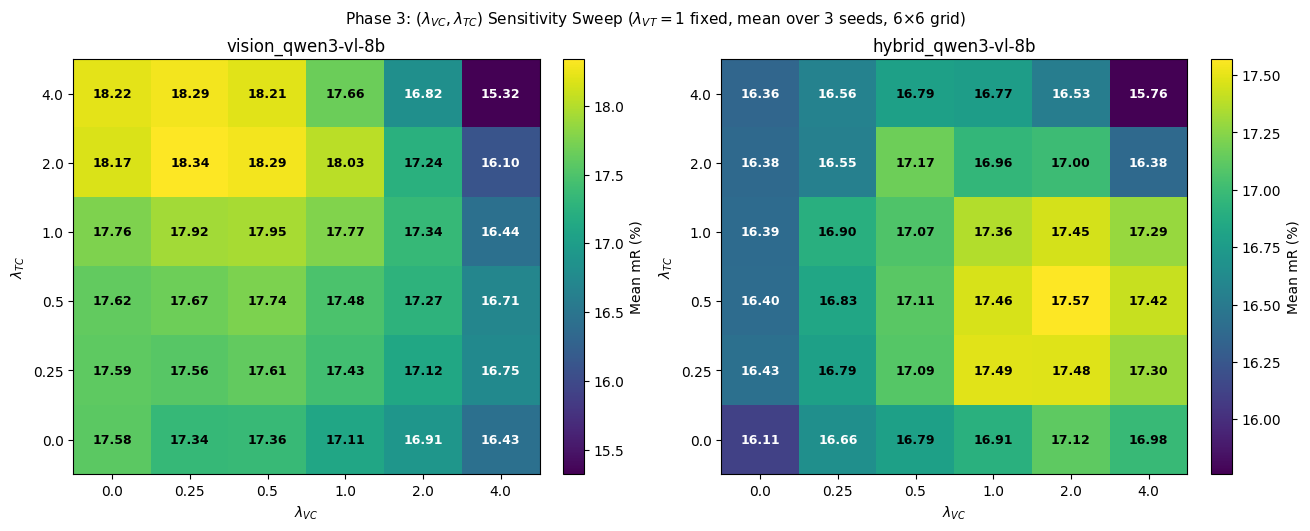

Figure saved: figures/phase3_lambda_heatmap.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

for ax, caption in zip(axes, CAPTIONS):
    grid = (agg[agg["caption"] == caption]
            .pivot(index="lambda_tc", columns="lambda_vc", values="mean")
            .sort_index(ascending=False))  # high lambda_tc at top

    im = ax.imshow(grid.values, aspect="auto", cmap="viridis",
                   interpolation="nearest")

    # Use the heatmap's value range to decide annotation color per cell
    vmin, vmax = grid.values.min(), grid.values.max()
    threshold = vmin + 0.55 * (vmax - vmin)

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid.values[i, j]
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if val < threshold else "black",
                    fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(LAMBDA_GRID)))
    ax.set_xticklabels(LAMBDA_GRID)
    ax.set_yticks(range(len(LAMBDA_GRID)))
    ax.set_yticklabels(sorted(LAMBDA_GRID, reverse=True))
    ax.set_xlabel(r"$\lambda_{VC}$")
    ax.set_ylabel(r"$\lambda_{TC}$")
    ax.set_title(caption)
    plt.colorbar(im, ax=ax, label="Mean mR (%)")

fig.suptitle(r"Phase 3: $(\lambda_{VC}, \lambda_{TC})$ Sensitivity Sweep "
             r"($\lambda_{VT} = 1$ fixed, mean over 3 seeds, 6$\times$6 grid)",
             fontsize=11)
plt.savefig(FIGURE_DIR / "phase3_lambda_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'phase3_lambda_heatmap.png'}")

In [18]:
# Identify the best (lambda_vc, lambda_tc) per caption
print("Best operating point per caption (highest mean mR):\n")
for caption in CAPTIONS:
    sub = agg[agg["caption"] == caption].copy()
    best = sub.loc[sub["mean"].idxmax()]
    phase2_full = sub.query("lambda_vc == 1.0 and lambda_tc == 1.0").iloc[0]
    delta = best["mean"] - phase2_full["mean"]
    print(f"{caption}")
    print(f"  best:   lambda_vc={best['lambda_vc']}, lambda_tc={best['lambda_tc']}, "
          f"mR={best['mean']:.2f} +/- {best['std']:.2f}")
    print(f"  Phase 2 (M-full): mR={phase2_full['mean']:.2f} +/- {phase2_full['std']:.2f}")
    print(f"  improvement from sweep: {delta:+.2f} mR\n")

Best operating point per caption (highest mean mR):

vision_qwen3-vl-8b
  best:   lambda_vc=0.25, lambda_tc=2.0, mR=18.34 +/- 0.17
  Phase 2 (M-full): mR=17.77 +/- 0.16
  improvement from sweep: +0.57 mR

hybrid_qwen3-vl-8b
  best:   lambda_vc=2.0, lambda_tc=0.5, mR=17.57 +/- 0.19
  Phase 2 (M-full): mR=17.36 +/- 0.33
  improvement from sweep: +0.21 mR



## 10. Save All Results

JSON for downstream use

In [19]:
final = {
    "experiment": "phase3_lambda_sweep",
    "lambda_grid": LAMBDA_GRID,
    "lambda_vt_fixed": LAMBDA_VT_FIXED,
    "captions": CAPTIONS,
    "seeds": SEEDS,
    "test_set_size": int(len(image_features["test"])),
    "k_values": K_VALUES,
    "runs": all_runs,
    "aggregated_grid": agg.to_dict("records"),
}

with open(RESULTS_JSON, "w") as f:
    json.dump(final, f, indent=2, default=lambda o: float(o) if hasattr(o, "item") else str(o))
print(f"Results saved: {RESULTS_JSON}")

Results saved: results/phase3_lambda_sweep.json
